# Analisis Data Eksploratif (EDA) Mendalam - Dataset Tumor Otak

Notebook ini menyajikan analisis data eksploratif (EDA) yang komprehensif dari dataset gambar Tumor Otak untuk menemukan *insight*, memahami distribusi data, dan mempersiapkan data untuk pemodelan machine learning. Analisis ini mencakup analisis visual, properti statistik dari gambar, dan representasi tingkat lanjut seperti *Mean Images* (Rata-rata Gambar) dan *Edge Detection* (Deteksi Tepi), yang sangat informatif dan cocok digunakan sebagai bahan presentasi.

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi gaya visual plot
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Memuat Data dan Tinjauan Awal
Mari kita kumpulkan *path* (lokasi file) gambar dan menyusunnya ke dalam bentuk DataFrame terstruktur agar analisis lebih mudah dilakukan.

In [2]:
dataset_path = 'brain_tumor_dataset'
classes = ['no', 'yes']

data = []
for cl in classes:
    paths = glob(os.path.join(dataset_path, cl, '*'))
    for path in paths:
        data.append({'filepath': path, 'label': cl})

df = pd.DataFrame(data)
display(df.head())
print(f"Total jumlah gambar divalidasi: {len(df)}")

,filepath,label
0,brain_tumor_dataset\no\1 no.jpeg,no
1,brain_tumor_dataset\no\10 no.jpg,no
2,brain_tumor_dataset\no\11 no.jpg,no
3,brain_tumor_dataset\no\12 no.jpg,no
4,brain_tumor_dataset\no\13 no.jpg,no


Total jumlah gambar divalidasi: 253


## 2. Distribusi Kelas
Sangat penting untuk memeriksa apakah dataset kita seimbang (*balanced*) atau tidak (*imbalanced*). Dataset yang terlalu timpang dapat menyebabkan model *deep learning* menjadi bias saat memprediksi.

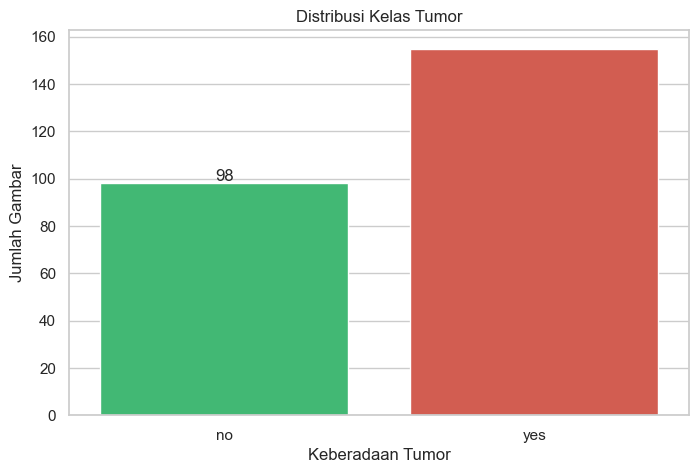

In [3]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette={'no': '#2ecc71', 'yes': '#e74c3c'})
ax.bar_label(ax.containers[0])
plt.title('Distribusi Kelas Tumor')
plt.xlabel('Keberadaan Tumor')
plt.ylabel('Jumlah Gambar')
plt.show()

## 3. Visualisasi Sampel Gambar
Memvisualisasikan beberapa contoh gambar dari setiap kelas untuk melihat langsung seperti apa rupa dari hasil pindai (scan) MRI pada dataset kita.

Contoh Sampel Tanpa Tumor (`no`)


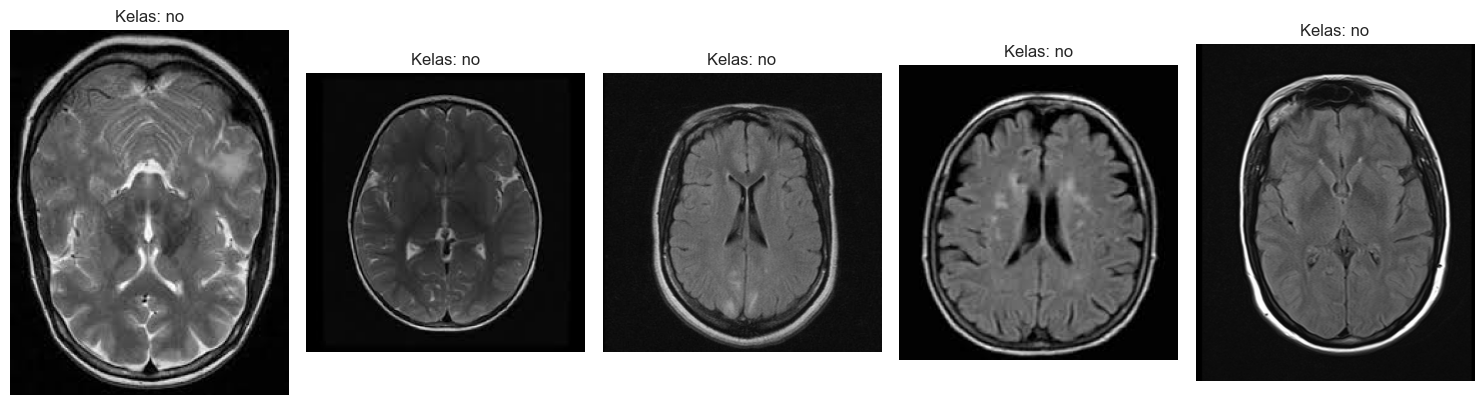

Contoh Sampel Dengan Tumor (`yes`)


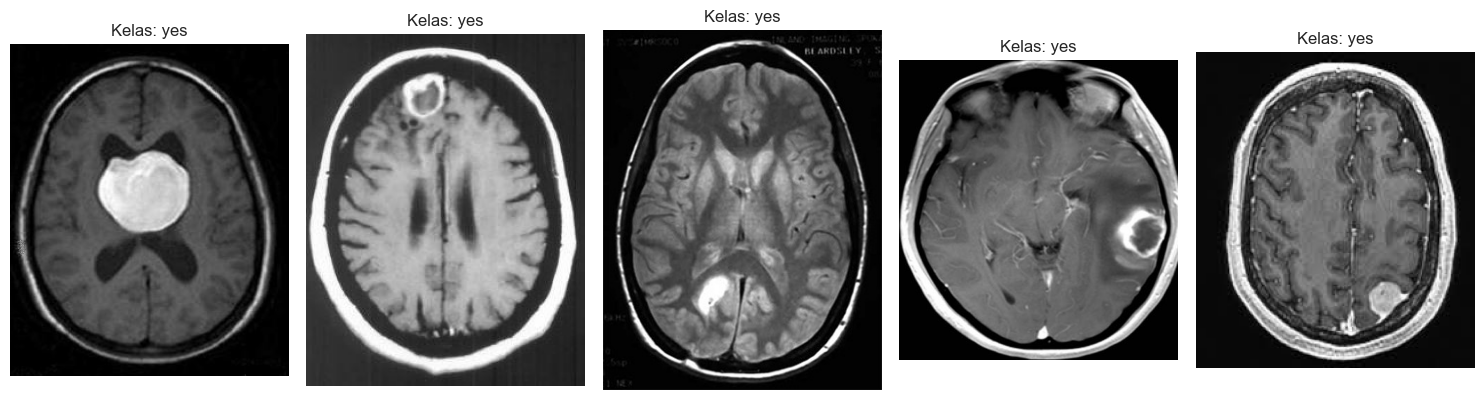

In [4]:
def plot_samples(df, label, n=5):
    samples = df[df['label'] == label].sample(n=n, random_state=42)['filepath'].values
    plt.figure(figsize=(15, 5))
    for i, path in enumerate(samples):
        plt.subplot(1, n, i+1)
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.title(f'Kelas: {label}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Contoh Sampel Tanpa Tumor (`no`)")
plot_samples(df, 'no')
print("Contoh Sampel Dengan Tumor (`yes`)")
plot_samples(df, 'yes')

## 4. Analisis Metadata Gambar (Dimensi & Rasio Aspek)
Gambar pada dataset dunia nyata seringkali memiliki dimensi resolusi yang bervariasi. Kita perlu menganalisis variasi ini untuk menentukan strategi penyesuaian ukuran (*resizing*) yang paling optimal untuk model CNN (Convolutional Neural Network) kita nantinya.

In [5]:
def get_image_info(path):
    try:
        with Image.open(path) as img:
            width, height = img.size
            return width, height, width/height
    except:
        return np.nan, np.nan, np.nan

tqdm.pandas(desc="Mengekstrak Metadata Dimensi")
df[['width', 'height', 'aspect_ratio']] = df['filepath'].progress_apply(
    lambda x: pd.Series(get_image_info(x))
)
df = df.dropna()

Mengekstrak Metadata Dimensi:   0%|          | 0/253 [00:00<?, ?it/s]

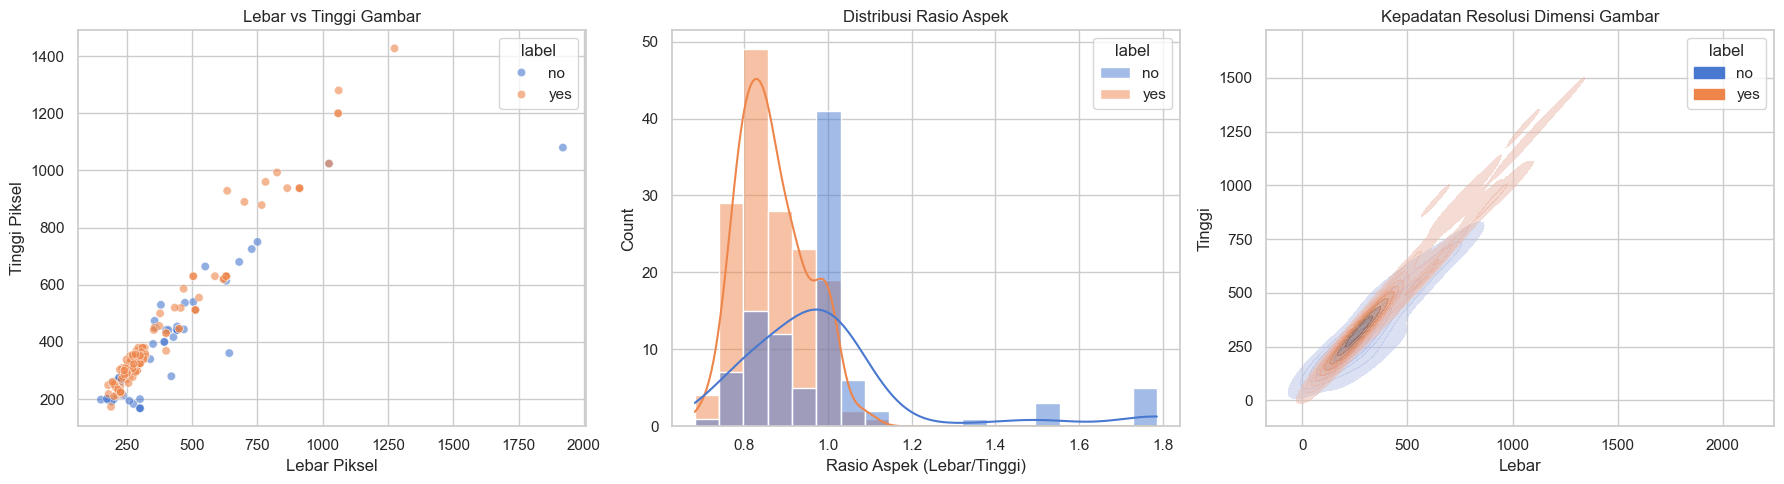

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter (Lebar vs Tinggi)
sns.scatterplot(data=df, x='width', y='height', hue='label', alpha=0.6, ax=axes[0])
axes[0].set_title('Lebar vs Tinggi Gambar')
axes[0].set_xlabel('Lebar Piksel')
axes[0].set_ylabel('Tinggi Piksel')

# Distribusi Rasio Aspek
sns.histplot(data=df, x='aspect_ratio', hue='label', kde=True, ax=axes[1])
axes[1].set_title('Distribusi Rasio Aspek')
axes[1].set_xlabel('Rasio Aspek (Lebar/Tinggi)')

# Density Dimensi Gambar KDE
sns.kdeplot(data=df, x='width', y='height', hue='label', fill=True, alpha=0.5, ax=axes[2])
axes[2].set_title('Kepadatan Resolusi Dimensi Gambar')
axes[2].set_xlabel('Lebar')
axes[2].set_ylabel('Tinggi')

plt.tight_layout()
plt.show()

## 5. Distribusi Intensitas Piksel
Menganalisis bagaimana rata-rata tingkat kecerahan (intensitas piksel) berbeda antara scan MRI otak dengan tumor dan otak sehat. Gambar medis / MRI sering memiliki variasi besar dalam hal pencahayaan dan kontras mesin.

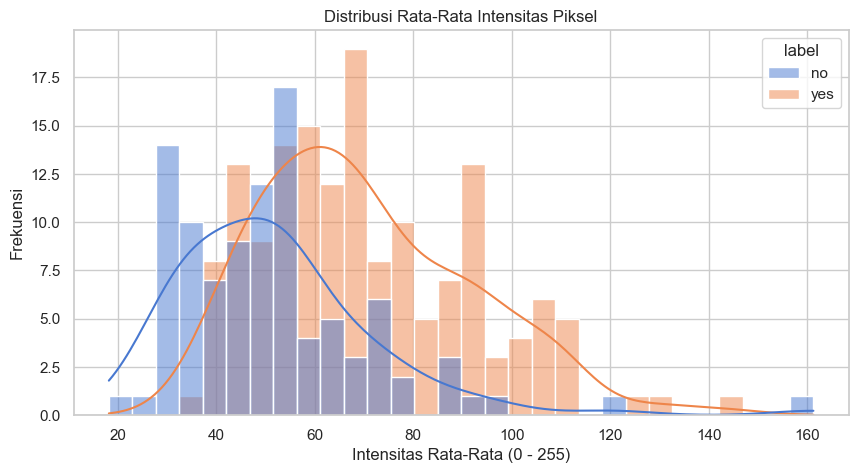

In [7]:
def get_average_intensity(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        return np.mean(img)
    return np.nan

df['mean_intensity'] = df['filepath'].apply(get_average_intensity)

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='mean_intensity', hue='label', kde=True, bins=30)
plt.title('Distribusi Rata-Rata Intensitas Piksel')
plt.xlabel('Intensitas Rata-Rata (0 - 255)')
plt.ylabel('Frekuensi')
plt.show()

## 6. Representasi Rata-Rata Gambar (Mean Image) Tiap Kelas
Seperti apa visualisasi gabungan dari "Rata-Rata" MRI Otak Ber-Tumor vs Sehat? 
Kita dapat menghitung *Mean Image* ini dengan merata-ratakan nilai piksel dari seluruh kumpulan gambar pada suatu kelas setelah melakukan standardisasi ukuran (misal 128x128). Representasi ini akan memperlihatkan letak kecenderungan anomali bentuk pada kelas ber-tumor.

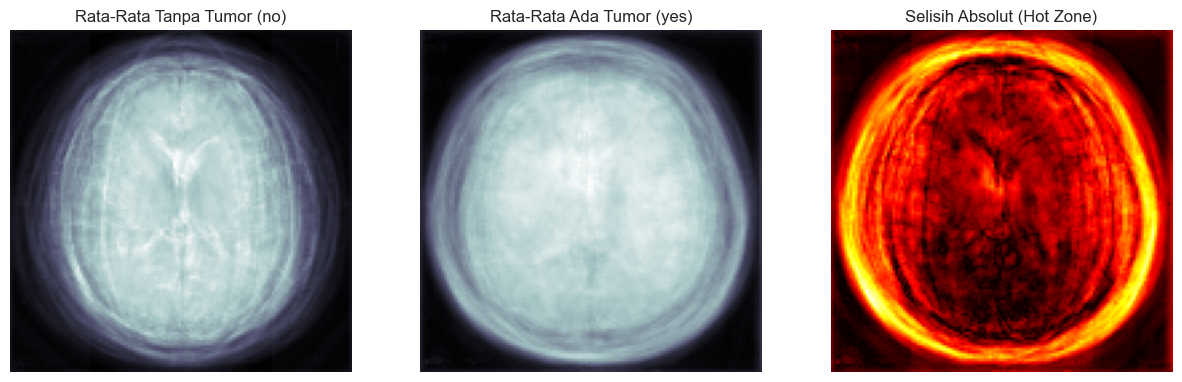

In [8]:
def compute_mean_image(paths, size=(128, 128)):
    images = []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, size)
            images.append(img)
    return np.mean(images, axis=0)

mean_no = compute_mean_image(df[df['label'] == 'no']['filepath'].values)
mean_yes = compute_mean_image(df[df['label'] == 'yes']['filepath'].values)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
axes[0].imshow(mean_no, cmap='bone')
axes[0].set_title('Rata-Rata Tanpa Tumor (no)')
axes[0].axis('off')

axes[1].imshow(mean_yes, cmap='bone')
axes[1].set_title('Rata-Rata Ada Tumor (yes)')
axes[1].axis('off')

diff_img = np.abs(mean_yes - mean_no)
axes[2].imshow(diff_img, cmap='hot')
axes[2].set_title('Selisih Absolut (Hot Zone)')
axes[2].axis('off')

plt.show()

## 7. Komparasi Deteksi Tepi (Pendeteksian Canny Edge)
Algoritma deteksi tepi (seperti Filter Canny) sering digunakan untuk mengekstraksi garis anatomis batas tulang dan jaringan otak. Massa tumor biasanya menghasilkan tepi struktural tak beraturan yang menonjol dan padat, yang kemudian kelak akan menjadi fitur kuat yang dipelajari otomatis oleh model berbasis konvolusi (CNN).

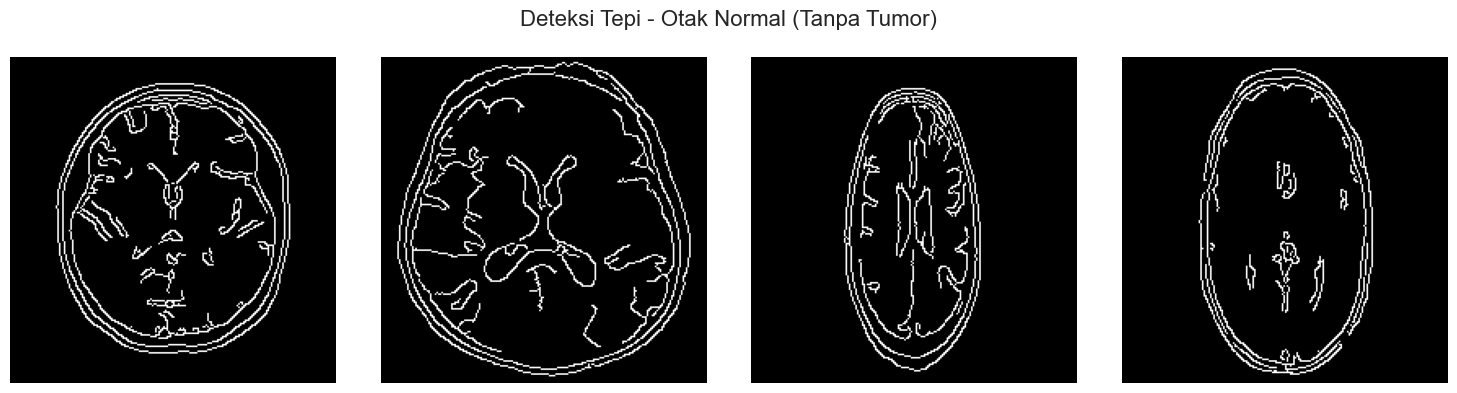

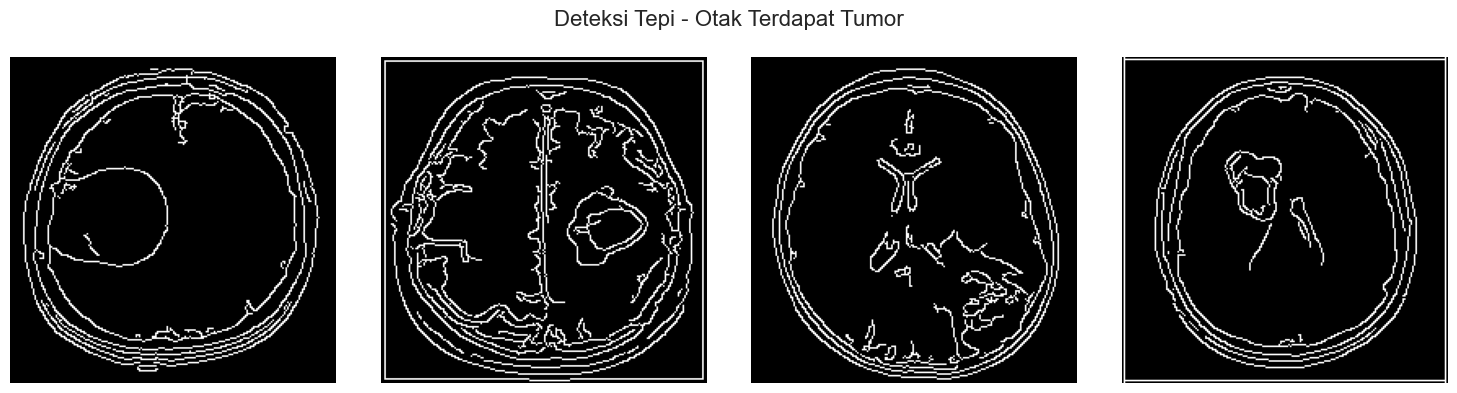

In [9]:
def plot_edges(paths, title):
    plt.figure(figsize=(15, 4))
    for i, path in enumerate(paths[:4]):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = cv2.resize(img, (200, 200))
        # Menggunakan Gaussian Blur ringan guna membuang noise MRI
        blurred = cv2.GaussianBlur(img, (5, 5), 0)
        # Melakukan proses deteksi tepi canny
        edges = cv2.Canny(blurred, 50, 150)
        
        plt.subplot(1, 4, i+1)
        plt.imshow(edges, cmap='gray')
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_edges(df[df['label'] == 'no']['filepath'].values, "Deteksi Tepi - Otak Normal (Tanpa Tumor)")
plot_edges(df[df['label'] == 'yes']['filepath'].values, "Deteksi Tepi - Otak Terdapat Tumor")

---

# Evaluasi Data Processing Berdasarkan Insight EDA

Pada bagian ini, kita akan menguji dan memvisualisasikan bagaimana langkah **Pra-pemrosesan Data (Data Preprocessing) yang ideal** dapat memperbaiki berbagai kelemahan bawaan gambar medis (seperti *distortion* / kemelaran rasio dan kontras mesin x-ray yang buram). Ini akan meningkatkan kemampuan model CNN kita secara dramatis dibandingkan hanya memberikan gambar mentah.

## 1. Pemecahan Masalah Rasio Aspek: Padding vs Stretching Keras Default
Fungsi _default_ `ImageDataGenerator` di Keras selalu melakukan _stretching_ (penarikan paksa memanjang/melebar) untuk menyesuaikan `target_size`. Distorsi organ ini bisa sangat merugikan dalam kasus klasifikasi medis. Berikut perbedaannya jika kita menggunakan metode penambahan pad (*padding*).

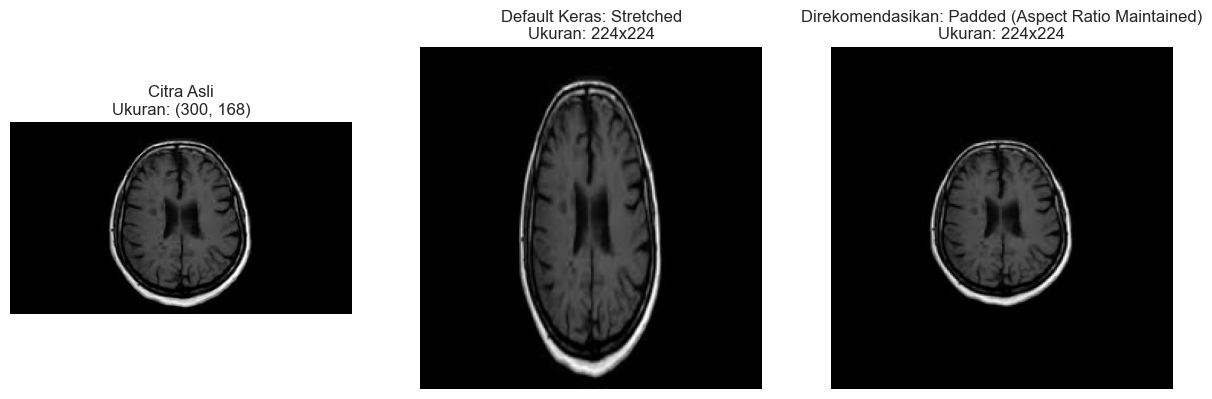

In [10]:
def resize_with_pad(img, expected_size):
    # Mengisi kotak hitam (pad) agar gambar menjadi persegi tanpa mendistorsi anatomi
    old_size = img.size
    ratio = float(expected_size)/max(old_size)
    new_size = tuple([int(x*ratio) for x in old_size])
    img = img.resize(new_size, Image.Resampling.LANCZOS)
    new_img = Image.new("RGB", (expected_size, expected_size))
    new_img.paste(img, ((expected_size-new_size[0])//2,
                        (expected_size-new_size[1])//2))
    return new_img

extreme_img_path = df.iloc[df['aspect_ratio'].idxmax()]['filepath']
img_pil = Image.open(extreme_img_path)

TARGET_SIZE = 224
# Menggunakan Stretching Default Keras (Buruk untuk medis)
stretched_img = img_pil.resize((TARGET_SIZE, TARGET_SIZE))

# Menggunakan Metode Preserving Aspect Ratio (Padding)
padded_img = resize_with_pad(img_pil, TARGET_SIZE)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_pil)
axes[0].set_title(f'Citra Asli\nUkuran: {img_pil.size}')
axes[0].axis('off')

axes[1].imshow(stretched_img)
axes[1].set_title(f'Default Keras: Stretched\nUkuran: {TARGET_SIZE}x{TARGET_SIZE}')
axes[1].axis('off')

axes[2].imshow(padded_img)
axes[2].set_title(f'Direkomendasikan: Padded (Aspect Ratio Maintained)\nUkuran: {TARGET_SIZE}x{TARGET_SIZE}')
axes[2].axis('off')

plt.show()

## 2. Pemecahan Masalah Kontras Pencahayaan: CLAHE (Contrast Limited Adaptive Histogram Equalization)
Dataset kita membuktikan bahwa distribusi intensitas piksel (kecerahan sinar MRI) rentannya jauh (ada yang sangat buram, ada yang putih menyilaukan mata tulang-tulangnya). `rescale=1./255` tidak memperbaiki tingkat buram. Kita direkomendasikan menerapkan CLAHE untuk mempertegas batas gumpalan tumor dari kabut x-ray.

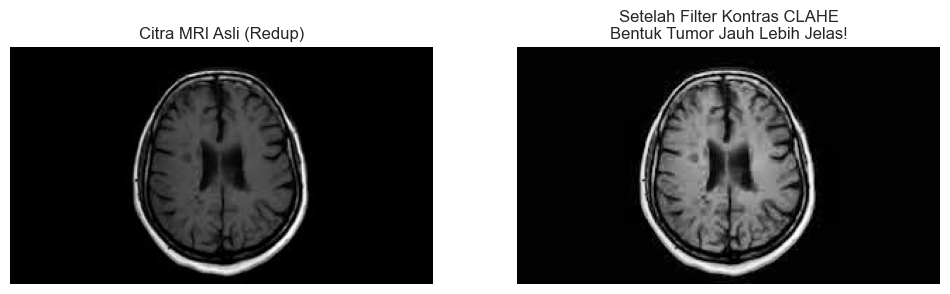

In [11]:
def apply_clahe(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    # CLAHE Initialization
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_clahe = clahe.apply(img)
    return img, img_clahe

dim_img_path = df.iloc[df['mean_intensity'].idxmin()]['filepath']
orig_dim, clahe_dim = apply_clahe(dim_img_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(orig_dim, cmap='gray')
axes[0].set_title('Citra MRI Asli (Redup)')
axes[0].axis('off')

axes[1].imshow(clahe_dim, cmap='gray')
axes[1].set_title('Setelah Filter Kontras CLAHE\nBentuk Tumor Jauh Lebih Jelas!')
axes[1].axis('off')

plt.show()

## 3. Evaluasi Augmentasi: Pilihan Ideal vs Terlalu Ekstrem
Penggunaan `shear_range` (gesekan) melintirkan batok tulang secara tak wajar yang tidak ditemui dalam kondisi alamiah. Sebaliknya, hal seperti pilar (*height_shift*), kelemahan posisi mesin (*rotation*), serta *flipping* otak adalah augmentasi yang terukur sesuai kondisi nyata rumah sakit.

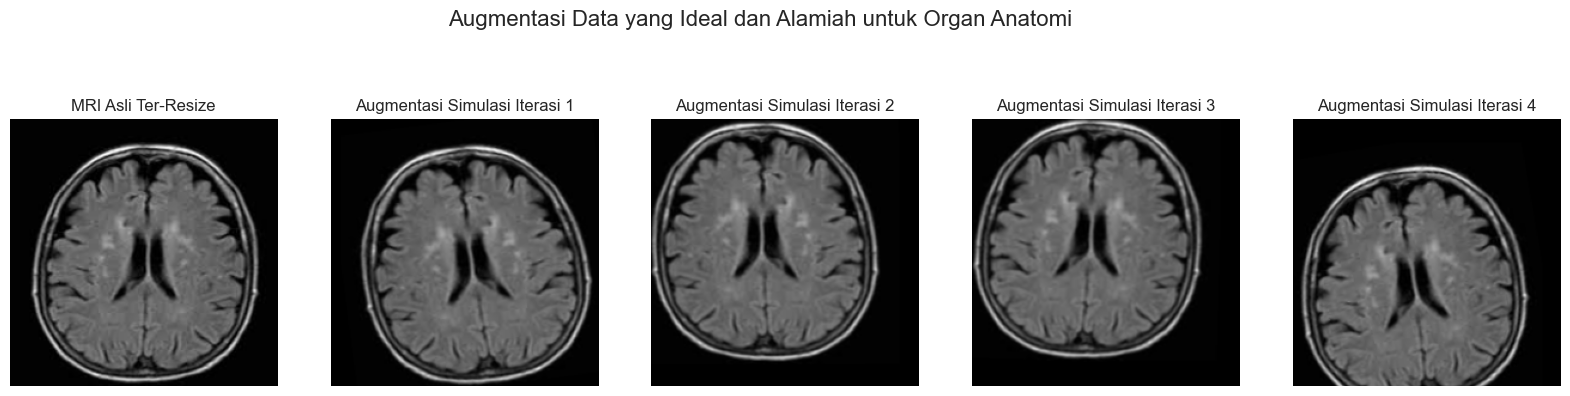

In [12]:
# Simulasi Keras ImageDataGenerator Augmentation
# Menggunakan murni OpenCV agar demonstrasi ini dapat berjalan independen tanpa library besar (Tensorflow)

def augment_image_demo(image):
    # 1. Flip
    img = cv2.flip(image, 1) if np.random.rand() > 0.5 else image
    
    # 2. Rotate (-10 to 10 degrees)
    rows, cols = img.shape[:2]
    angle = np.random.uniform(-10, 10)
    M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
    img = cv2.warpAffine(img, M, (cols, rows), borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
    
    # 3. Shift (translation -10% to 10%)
    tx = np.random.uniform(-0.1, 0.1) * cols
    ty = np.random.uniform(-0.1, 0.1) * rows
    M_shift = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M_shift, (cols, rows), borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
    
    return img

sample_img = cv2.imread(df.iloc[7]['filepath'])
sample_img = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)
sample_img = cv2.resize(sample_img, (224, 224))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
axes[0].imshow(sample_img)
axes[0].set_title('MRI Asli Ter-Resize')
axes[0].axis('off')

# Hasil 4 Augmentasi
for i in range(1, 5):
    aug_img = augment_image_demo(sample_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmentasi Simulasi Iterasi {i}')
    axes[i].axis('off')
        
plt.suptitle("Augmentasi Data yang Ideal dan Alamiah untuk Organ Anatomi", fontsize=16)
plt.show()

## Kesimpulan Integrasi Akhir untuk Pipeline Model:

Dari penjabaran visual evaluasi *preprocessing* medis di atas, kita dapat merangkum pipeline data yang 100% matang untuk tugas klasifikasi ini sebagai berikut:
1. Terapkan fungsi pembungkus (wrapper) OpenCV **CLAHE** saat me-*load* gambar.
2. Terapkan teknik ukuran cerdas (**Zero Padding**) ketimbang *stretching* default dengan cara mendelegasikan resizing dari *generator* ke fungsi Lambda khusus.
3. Hapus parameter `shear_range` dan tahan `rotation_range` di bawah tingkat 15 derajat untuk mempertahankan geometri tengkorak manusia (*biomedical logic*).